In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [147]:
data = pd.read_csv('insurance.csv')
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

In [148]:
#Check rows and columns
data.shape

(1338, 7)

In [149]:
#Name all columns name
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [150]:
#Check data types
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [151]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [152]:
#Check missing values
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [153]:
#Check duplicates rows
data.duplicated().sum() #there is one duplicate

np.int64(1)

In [154]:
data[data.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [155]:
#Remove the duplicate row
data.drop_duplicates(inplace=True)

In [156]:
#now we can see the shape,,,,compare with upper shape
data.shape

(1337, 7)

In [157]:
#Checking numeric statistics
data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [158]:
#check unique values
data['sex'].unique()

array(['female', 'male'], dtype=object)

In [159]:
data['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [160]:
data['smoker'].unique()

array(['yes', 'no'], dtype=object)

In [161]:
numeric_columns = data.select_dtypes(include='number').columns
numeric_columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

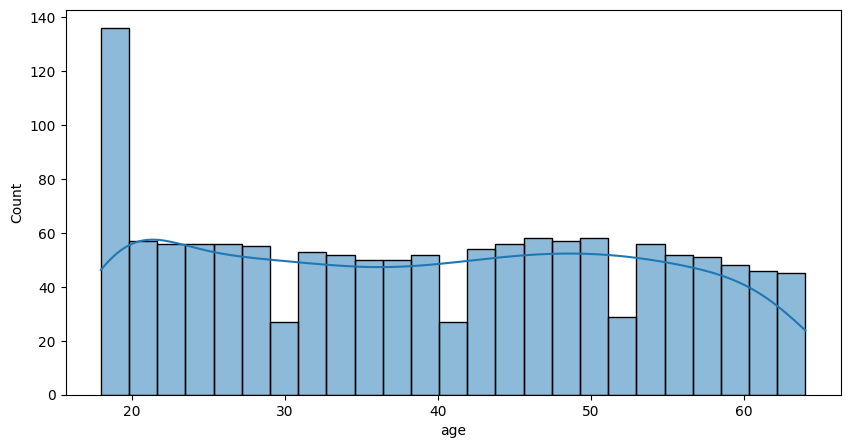

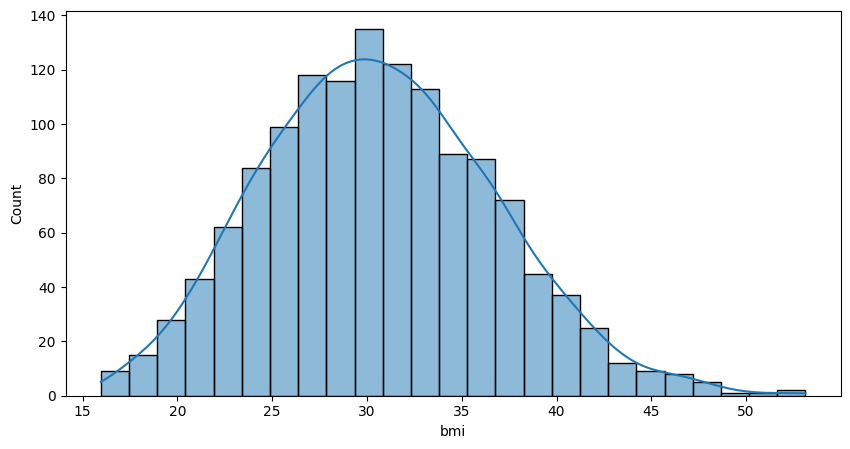

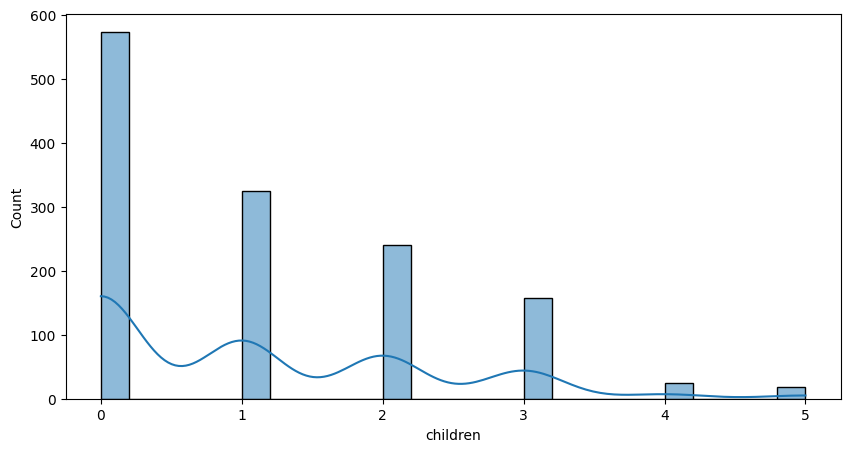

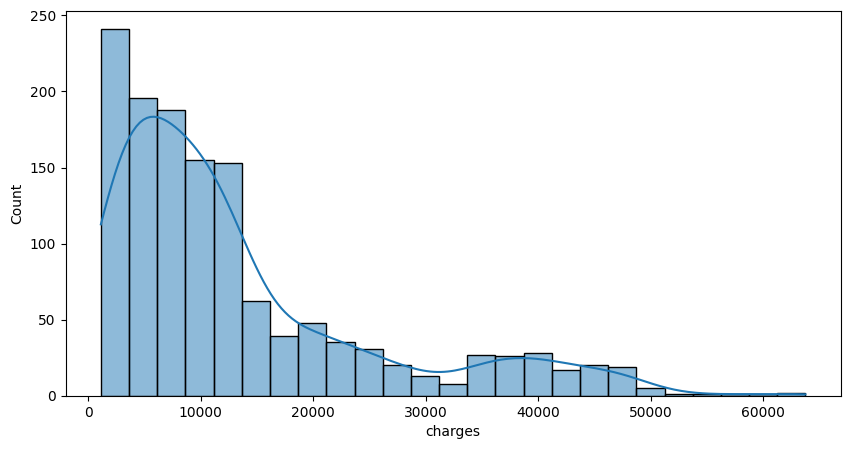

In [162]:
for col in numeric_columns:
  plt.figure(figsize=(10,5))
  sns.histplot(data[col],kde=True,bins = 25)

In [163]:
#check categorial columns
categorial_columns = data[data.select_dtypes(include='object').columns]
categorial_columns

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [164]:
data['sex'].value_counts()

,count
sex,
male,675
female,662


In [165]:
data['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [166]:
data['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


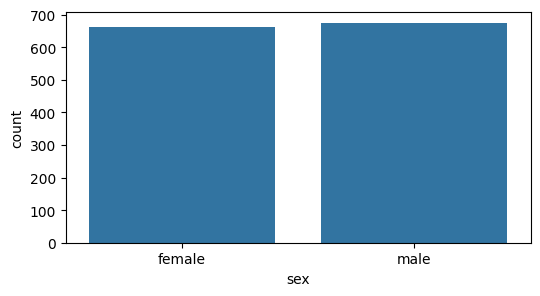

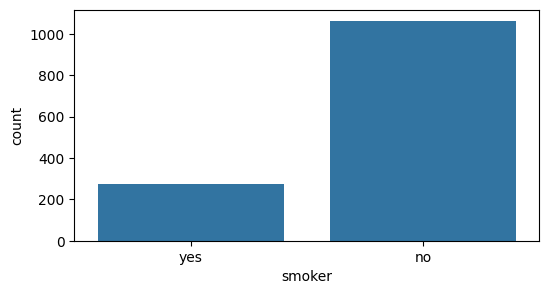

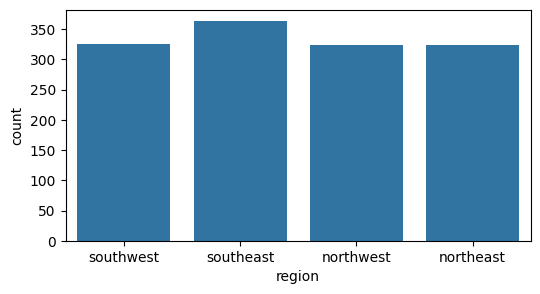

In [167]:
for col in categorial_columns:
  plt.figure(figsize=(6,3))
  sns.countplot(data=data,x = col)

## Detect Outliers

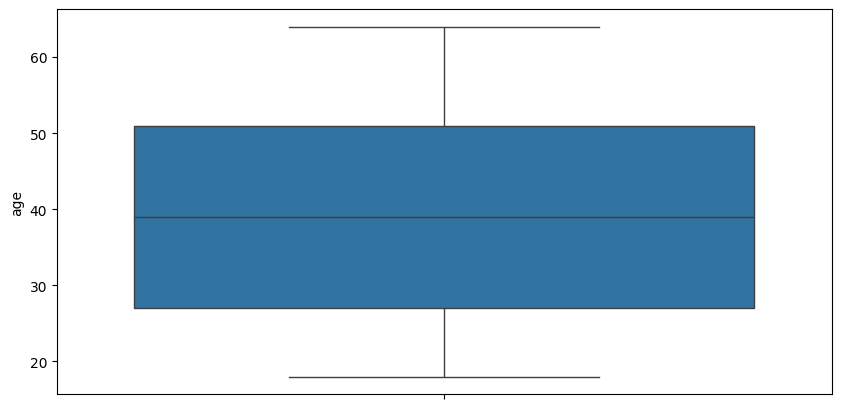

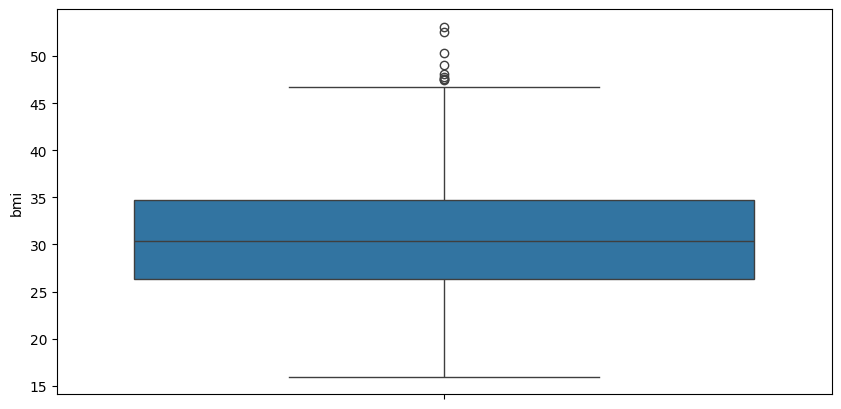

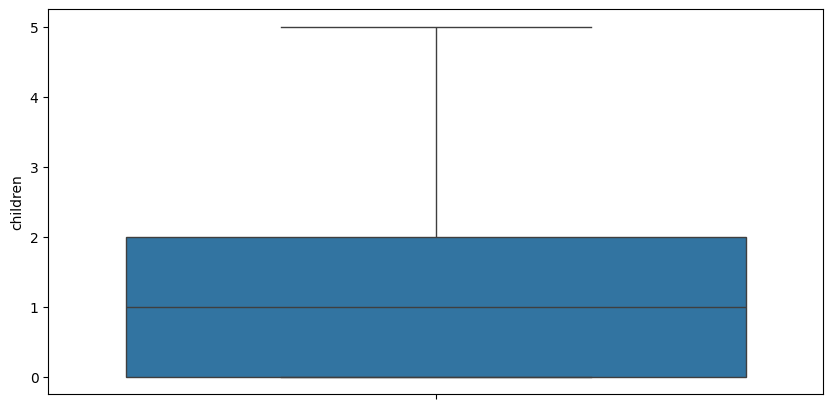

In [168]:
for col in numeric_columns[0:3]:
  plt.figure(figsize=(10,5))
  sns.boxplot(data[col])

# Data Cleaning

In [169]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [170]:
data.shape

(1337, 7)

In [171]:
clean_data = data.copy()
clean_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [172]:
clean_data.shape

(1337, 7)

In [173]:
clean_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [174]:
#Doing Label Encoding for 'sex' and 'smoker'
#basically converting categorial data  into 0 and 1
clean_data['sex'] = clean_data['sex'].map({'male':0,'female': 1})

In [175]:
clean_data['smoker'] = clean_data['smoker'].map({'yes':0,'no':1})

In [176]:
clean_data

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [177]:
#Doing One-hot Encoding for more that 2 values in a particular data.
clean_data = pd.get_dummies(clean_data,columns=['region'])
clean_data


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,0,16884.92400,False,False,False,True
1,18,0,33.770,1,1,1725.55230,False,False,True,False
2,28,0,33.000,3,1,4449.46200,False,False,True,False
3,33,0,22.705,0,1,21984.47061,False,True,False,False
4,32,0,28.880,0,1,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,10600.54830,False,True,False,False
1334,18,1,31.920,0,1,2205.98080,True,False,False,False
1335,18,1,36.850,0,1,1629.83350,False,False,True,False
1336,21,1,25.800,0,1,2007.94500,False,False,False,True


In [178]:
#convert it into int
clean_data = clean_data.astype(int)
clean_data

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,0,16884,0,0,0,1
1,18,0,33,1,1,1725,0,0,1,0
2,28,0,33,3,1,4449,0,0,1,0
3,33,0,22,0,1,21984,0,1,0,0
4,32,0,28,0,1,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,0,1,0,0
1334,18,1,31,0,1,2205,1,0,0,0
1335,18,1,36,0,1,1629,0,0,1,0
1336,21,1,25,0,1,2007,0,0,0,1


In [179]:
#google it and see what categories does bmi have
"""
Underweight: BMI below 18.5
Healthy Weight: BMI 18.5 to 24.9
Overweight: BMI 25.0 to 29.9
Obesity Class I: BMI 30.0 to 34.9
Obesity Class II: BMI 35.0 to 39.9
Obesity Class III (Severe): BMI 40.0 or greater

"""

clean_data["bmi_Category"] = pd.cut(
    clean_data["bmi"],
    bins=[-float("inf"), 18.5, 25.0, 30.0, 35.0, 40.0, float("inf")],
    labels=[
        "Underweight",
        "Healthy Weight",
        "Overweight",
        "Obesity Class I",
        "Obesity Class II",
        "Obesity Class III (Severe)"
    ]
)




In [180]:
clean_data

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_Category
0,19,1,27,0,0,16884,0,0,0,1,Overweight
1,18,0,33,1,1,1725,0,0,1,0,Obesity Class I
2,28,0,33,3,1,4449,0,0,1,0,Obesity Class I
3,33,0,22,0,1,21984,0,1,0,0,Healthy Weight
4,32,0,28,0,1,3866,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,0,1,0,0,Overweight
1334,18,1,31,0,1,2205,1,0,0,0,Obesity Class I
1335,18,1,36,0,1,1629,0,0,1,0,Obesity Class II
1336,21,1,25,0,1,2007,0,0,0,1,Healthy Weight


In [181]:
clean_data['bmi_Category'].value_counts()

,count
bmi_Category,
Overweight,404
Obesity Class I,357
Healthy Weight,293
Obesity Class II,191
Obesity Class III (Severe),68
Underweight,24


<Axes: xlabel='count', ylabel='bmi_Category'>

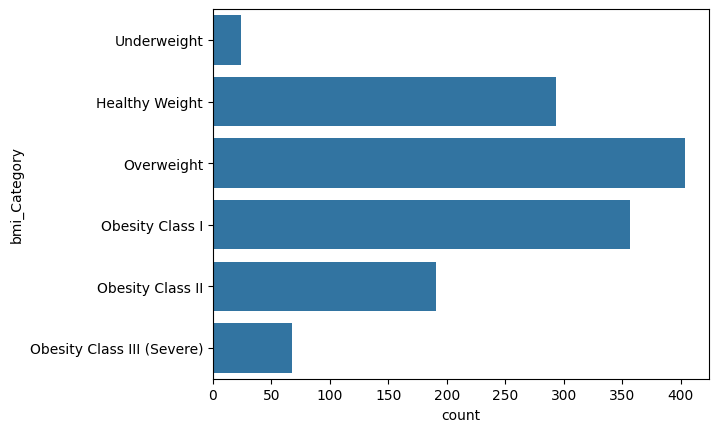

In [182]:
sns.countplot(data=clean_data, y ='bmi_Category')

In [183]:
#Lets do One-hot Encoding for bmi_categories
clean_data = pd.get_dummies(clean_data,columns=['bmi_Category'])
clean_data

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_Category_Underweight,bmi_Category_Healthy Weight,bmi_Category_Overweight,bmi_Category_Obesity Class I,bmi_Category_Obesity Class II,bmi_Category_Obesity Class III (Severe)
0,19,1,27,0,0,16884,0,0,0,1,False,False,True,False,False,False
1,18,0,33,1,1,1725,0,0,1,0,False,False,False,True,False,False
2,28,0,33,3,1,4449,0,0,1,0,False,False,False,True,False,False
3,33,0,22,0,1,21984,0,1,0,0,False,True,False,False,False,False
4,32,0,28,0,1,3866,0,1,0,0,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,0,1,0,0,False,False,True,False,False,False
1334,18,1,31,0,1,2205,1,0,0,0,False,False,False,True,False,False
1335,18,1,36,0,1,1629,0,0,1,0,False,False,False,False,True,False
1336,21,1,25,0,1,2007,0,0,0,1,False,True,False,False,False,False


In [184]:
clean_data = clean_data.astype(int)
clean_data


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_Category_Underweight,bmi_Category_Healthy Weight,bmi_Category_Overweight,bmi_Category_Obesity Class I,bmi_Category_Obesity Class II,bmi_Category_Obesity Class III (Severe)
0,19,1,27,0,0,16884,0,0,0,1,0,0,1,0,0,0
1,18,0,33,1,1,1725,0,0,1,0,0,0,0,1,0,0
2,28,0,33,3,1,4449,0,0,1,0,0,0,0,1,0,0
3,33,0,22,0,1,21984,0,1,0,0,0,1,0,0,0,0
4,32,0,28,0,1,3866,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,0,1,0,0,0,0,1,0,0,0
1334,18,1,31,0,1,2205,1,0,0,0,0,0,0,1,0,0
1335,18,1,36,0,1,1629,0,0,1,0,0,0,0,0,1,0
1336,21,1,25,0,1,2007,0,0,0,1,0,1,0,0,0,0


In [185]:
#If we see the data all columns has value 0 and 1 instead of 'age'
#'bmi'and 'children' don't include charges it is an output column.
"""
age ranges roughly 18–64
bmi ranges roughly 15–50
children ranges 0–5

"""
#StandardScaler is used to standardize numerical data so that each feature has:
#Mean = 0
#Standard deviation = 1

from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()
clean_data[cols] = scaler.fit_transform(clean_data[cols])
clean_data[cols]

#HERE,fit → calculates the mean and standard deviation of each column
#transform → converts the values using those statistics



,age,bmi,children
0,-1.440418,-0.517949,-0.909234
1,-1.511647,0.462463,-0.079442
2,-0.799350,0.462463,1.580143
3,-0.443201,-1.334960,-0.909234
4,-0.514431,-0.354547,-0.909234
...,...,...,...
1333,0.767704,-0.027743,1.580143
1334,-1.511647,0.135659,-0.909234
1335,-1.511647,0.952670,-0.909234
1336,-1.297958,-0.844753,-0.909234


In [186]:
clean_data

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_Category_Underweight,bmi_Category_Healthy Weight,bmi_Category_Overweight,bmi_Category_Obesity Class I,bmi_Category_Obesity Class II,bmi_Category_Obesity Class III (Severe)
0,-1.440418,1,-0.517949,-0.909234,0,16884,0,0,0,1,0,0,1,0,0,0
1,-1.511647,0,0.462463,-0.079442,1,1725,0,0,1,0,0,0,0,1,0,0
2,-0.799350,0,0.462463,1.580143,1,4449,0,0,1,0,0,0,0,1,0,0
3,-0.443201,0,-1.334960,-0.909234,1,21984,0,1,0,0,0,1,0,0,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,1,10600,0,1,0,0,0,0,1,0,0,0
1334,-1.511647,1,0.135659,-0.909234,1,2205,1,0,0,0,0,0,0,1,0,0
1335,-1.511647,1,0.952670,-0.909234,1,1629,0,0,1,0,0,0,0,0,1,0
1336,-1.297958,1,-0.844753,-0.909234,1,2007,0,0,0,1,0,1,0,0,0,0


In [187]:
#This computes the Pearson correlation coefficient between each feature and the target (charges), to see which features move together with cost linearly.
#In simple term persone correlation check the correlation of every features against(with) charges(target_variable)

selected_features = ['age', 'sex', 'bmi', 'children', 'smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_Category_Underweight',
       'bmi_Category_Healthy Weight', 'bmi_Category_Overweight',
       'bmi_Category_Obesity Class I', 'bmi_Category_Obesity Class II',
       'bmi_Category_Obesity Class III (Severe)']
Correlation ={}

for feature in selected_features:
  Correlation[feature] = clean_data['charges'].corr(clean_data[feature])

Correlation_data = pd.DataFrame(list(Correlation.items()),columns=['Features','Correlation'])
Correlation_data.sort_values(by='Correlation',ascending=False)




,Features,Correlation
0,age,0.298309
2,bmi,0.196236
13,bmi_Category_Obesity Class II,0.118872
12,bmi_Category_Obesity Class I,0.082859
14,bmi_Category_Obesity Class III (Severe),0.073783
7,region_southeast,0.073577
3,children,0.067390
5,region_northeast,0.005946
6,region_northwest,-0.038695
8,region_southwest,-0.043637


In [188]:
#Performing Chi Square Test:as we know that chi square test is only for categorial data
categorical_features = ['bmi_Category_Obesity Class II','bmi_Category_Obesity Class I',	'bmi_Category_Obesity Class III (Severe)',
                      'region_southeast','region_northeast','region_northwest','region_southwest',
                      'bmi_Category_Underweight','sex','bmi_Category_Overweight','bmi_Category_Healthy Weight',
                      'smoker']

from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

clean_data['charges_bin'] = pd.qcut(clean_data['charges'], q=4, labels=False)
chi2_results = {}

for col in categorical_features:
    contingency = pd.crosstab(clean_data[col], clean_data['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df



,chi2_statistic,p_value,Decision
smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
sex,10.258784,0.01649,Reject Null (Keep Feature)
bmi_Category_Obesity Class II,7.773364,0.050935,Accept Null (Drop Feature)
region_northeast,6.438442,0.092122,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_Category_Healthy Weight,4.771699,0.189298,Accept Null (Drop Feature)
bmi_Category_Overweight,4.450807,0.21672,Accept Null (Drop Feature)
bmi_Category_Underweight,3.37403,0.337471,Accept Null (Drop Feature)
bmi_Category_Obesity Class I,1.238129,0.743875,Accept Null (Drop Feature)


In [192]:
final_df = clean_data[['age','sex','bmi','children','smoker','region_southeast','bmi_Category_Obesity Class II','charges']]
final_df

,age,sex,bmi,children,smoker,region_southeast,bmi_Category_Obesity Class II,charges
0,-1.440418,1,-0.517949,-0.909234,0,0,0,16884
1,-1.511647,0,0.462463,-0.079442,1,1,0,1725
2,-0.799350,0,0.462463,1.580143,1,1,0,4449
3,-0.443201,0,-1.334960,-0.909234,1,0,0,21984
4,-0.514431,0,-0.354547,-0.909234,1,0,0,3866
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,1,0,0,10600
1334,-1.511647,1,0.135659,-0.909234,1,0,0,2205
1335,-1.511647,1,0.952670,-0.909234,1,1,1,1629
1336,-1.297958,1,-0.844753,-0.909234,1,0,0,2007


In [193]:
from sklearn.model_selection import train_test_split


In [194]:
X = final_df.drop('charges',axis = 1)
y = final_df['charges']

In [195]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42)

In [196]:
from sklearn.linear_model import LinearRegression

In [199]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [200]:
y_pred = model.predict(X_test)
y_pred

array([ 7859.80119167,  6042.90114585, 14752.42831242, 31703.86664655,
        9288.69457726, 13450.63743111, 30369.14033508,  1848.45347817,
       10399.51608932, 11274.46301073, 10616.79866981, 33194.64435533,
       30572.36922866, 17494.65404095, 10845.04087169,  9742.98788583,
        4502.22199329, 31678.80308387,  3538.98966702,  5135.64180377,
        3561.15431576, 30068.51217705, 14519.91599389, 30812.00885104,
       30960.17757941,  5372.24841646, 35791.13194031, 36672.48810287,
       10874.29291057, 13660.03734266,  6172.20383047, 13158.32342952,
         533.21621994, 12373.45561479, 39270.13115437, 12566.10612009,
        5001.83669564,  3956.36400397, 30866.24682612,  9049.75243296,
        6841.96668864, 30033.23442779, 34493.921109  , 11885.98376774,
        7381.5333723 ,  3634.48401619,  6149.67498004,  9088.26237256,
        4174.63024244,  8969.17387453,  6624.10456555, 11362.22274605,
       30988.27415178,  3479.10634351, 11092.75154219,  9610.26061774,
      

In [206]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)
r2

0.8047045581399161

In [209]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
adjusted_r2

0.7994466039359909